<a href="https://colab.research.google.com/github/Tapiwanashe6/linear_regression_model/blob/main/summative_part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import SGDRegressor
import joblib
import numpy as np

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ashishraut64/internet-users")

print("Path to dataset files:", path)

100%|██████████| 163k/163k [00:00<00:00, 52.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ashishraut64/internet-users/versions/1


In [ ]:
df = pd.read_csv('/root/.cache/kagglehub/datasets/ashishraut64/internet-users/versions/1/Final.csv')
df.head()

,Unnamed: 0,Entity,Code,Year,Cellular Subscription,Internet Users(%),No. of Internet Users,Broadband Subscription
0,0,Afghanistan,AFG,1980,0.0,0.0,0,0.0
1,1,Afghanistan,AFG,1981,0.0,0.0,0,0.0
2,2,Afghanistan,AFG,1982,0.0,0.0,0,0.0
3,3,Afghanistan,AFG,1983,0.0,0.0,0,0.0
4,4,Afghanistan,AFG,1984,0.0,0.0,0,0.0


In [ ]:
df.isna().any()

,0
Unnamed: 0,False
Entity,False
Code,False
Year,False
Cellular Subscription,False
Internet Users(%),False
No. of Internet Users,False
Broadband Subscription,False


In [ ]:
# ust making sure that all columns are not zero starting from Cellular subscription to the end like the table above
df.iloc[20:26]

,Unnamed: 0,Entity,Code,Year,Cellular Subscription,Internet Users(%),No. of Internet Users,Broadband Subscription
20,20,Afghanistan,AFG,2000,0.000000,0.000000,0,0.000000
21,21,Afghanistan,AFG,2001,0.000000,0.004723,930,0.000000
22,22,Afghanistan,AFG,2002,0.110616,0.004561,958,0.000000
23,23,Afghanistan,AFG,2003,0.844564,0.087891,19903,0.000000
24,24,Afghanistan,AFG,2004,2.426528,0.105809,24922,0.000809
25,25,Afghanistan,AFG,2005,4.677583,1.224148,298829,0.000858


In [ ]:
df.columns

Index(['Unnamed: 0', 'Entity', 'Code', 'Year', 'Cellular Subscription',
       'Internet Users(%)', 'No. of Internet Users', 'Broadband Subscription'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8867 entries, 0 to 8866
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              8867 non-null   int64  
 1   Entity                  8867 non-null   object 
 2   Code                    8867 non-null   object 
 3   Year                    8867 non-null   int64  
 4   Cellular Subscription   8867 non-null   float64
 5   Internet Users(%)       8867 non-null   float64
 6   No. of Internet Users   8867 non-null   int64  
 7   Broadband Subscription  8867 non-null   float64
dtypes: float64(3), int64(3), object(2)
memory usage: 554.3+ KB


In [ ]:
df.describe()


,Unnamed: 0,Year,Cellular Subscription,Internet Users(%),No. of Internet Users,Broadband Subscription
count,8867.000000,8867.000000,8867.000000,8867.000000,8.867000e+03,8867.000000
mean,4433.000000,2000.151799,39.989614,17.043606,1.089138e+07,4.440695
std,2559.826752,11.812151,51.981410,26.883498,1.248841e+08,9.755705
min,0.000000,1980.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,2216.500000,1990.000000,0.000000,0.000000,0.000000e+00,0.000000
50%,4433.000000,2000.000000,5.501357,0.855662,1.004700e+04,0.000000
75%,6649.500000,2010.000000,82.231594,25.449939,8.664195e+05,2.007603
max,8866.000000,2020.000000,436.103027,100.000000,4.699886e+09,78.524361


# Focusing on Rwanda Internet Use Only For my mission

In [ ]:
rwanda_df = df[df['Entity'] == 'Rwanda']
rwanda_df.head()

In [ ]:
# Drop useless columns
rwanda_df = rwanda_df.drop(columns=['Unnamed: 0', 'Code', 'Entity']).reset_index(drop=True)

In [ ]:
rwanda_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41 entries, 6698 to 6738
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              41 non-null     int64  
 1   Entity                  41 non-null     object 
 2   Code                    41 non-null     object 
 3   Year                    41 non-null     int64  
 4   Cellular Subscription   41 non-null     float64
 5   Internet Users(%)       41 non-null     float64
 6   No. of Internet Users   41 non-null     int64  
 7   Broadband Subscription  41 non-null     float64
dtypes: float64(3), int64(3), object(2)
memory usage: 2.9+ KB


In [ ]:
rwanda_df.columns

Index(['Year', 'Cellular Subscription', 'Internet Users(%)',
       'No. of Internet Users', 'Broadband Subscription'],
      dtype='object')

In [ ]:
rwanda_df.head()

,Year,Cellular Subscription,Internet Users(%),No. of Internet Users,Broadband Subscription
0,1980,0.0,0.0,0,0.0
1,1981,0.0,0.0,0,0.0
2,1982,0.0,0.0,0,0.0
3,1983,0.0,0.0,0,0.0
4,1984,0.0,0.0,0,0.0


In [ ]:
print(rwanda_df['Internet Users(%)'].corr(rwanda_df['No. of Internet Users']))

0.9977063225125673


# Dropping Internet Users(%) since correlation is almost equal to 1

In [ ]:
rwanda_df = rwanda_df.drop(columns='Internet Users(%)')

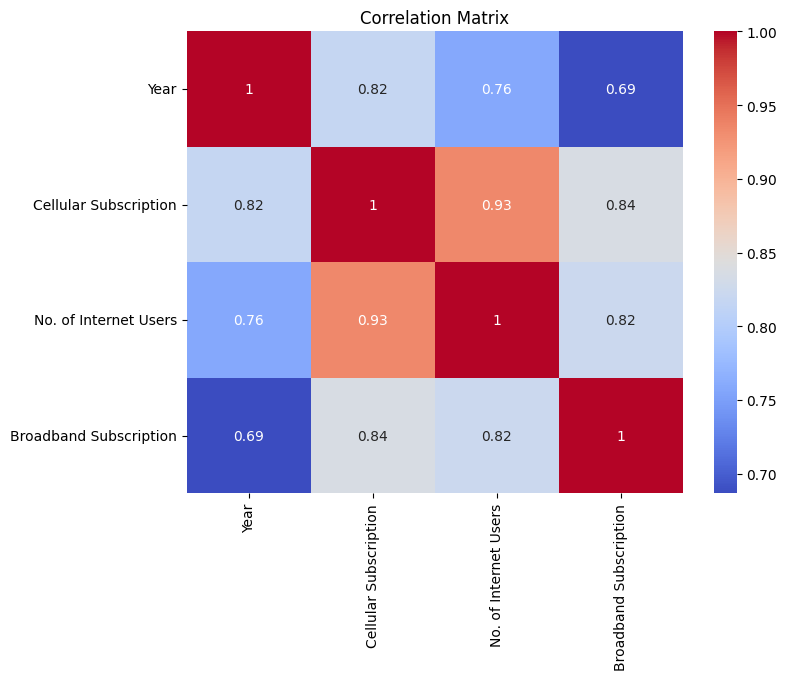

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(rwanda_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

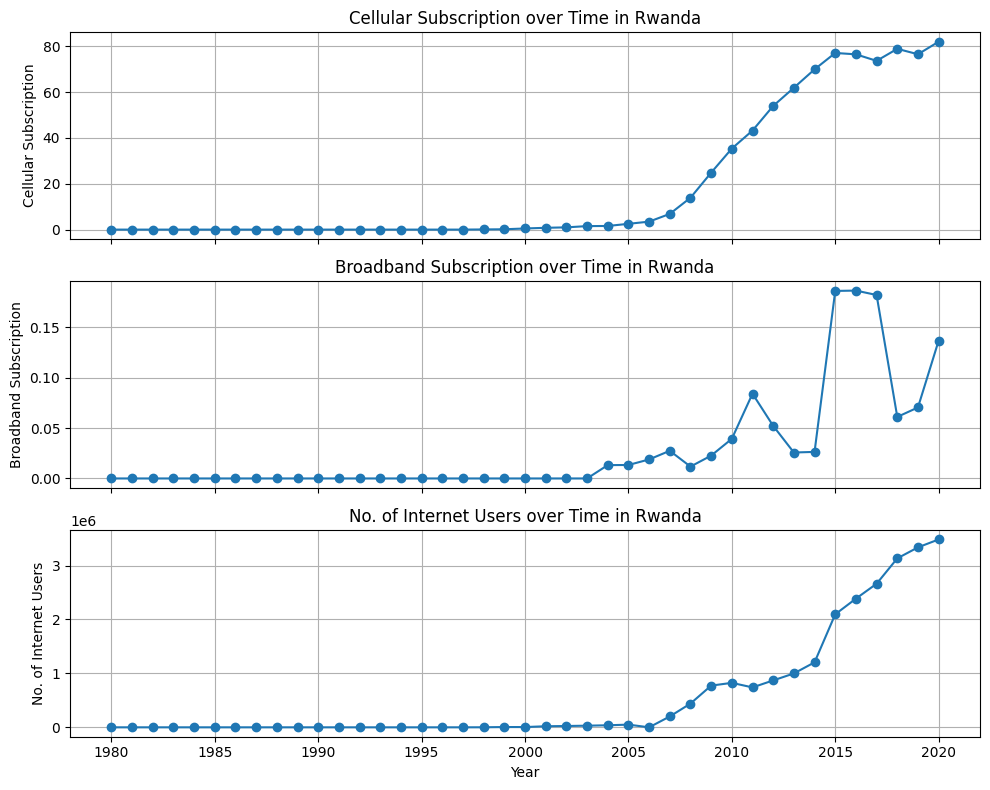

In [ ]:
# Features to plot
features = ['Cellular Subscription', 'Broadband Subscription', 'No. of Internet Users']

# Create subplots
fig, axes = plt.subplots(len(features), 1, figsize=(10, 8), sharex=True)

for i, feature in enumerate(features):
    axes[i].plot(rwanda_df['Year'], rwanda_df[feature], marker='o', linestyle='-')
    axes[i].set_ylabel(feature)
    axes[i].set_title(f'{feature} over Time in Rwanda')
    axes[i].grid(True)

# X-axis label only at the bottom
axes[-1].set_xlabel('Year')

plt.tight_layout()
plt.show()

In [ ]:
rwanda_df.columns

Index(['Year', 'Cellular Subscription', 'No. of Internet Users',
       'Broadband Subscription'],
      dtype='object')

# Standardizing the data

In [ ]:
# Features and target
X = rwanda_df[['Year', 'Cellular Subscription', 'Broadband Subscription']]
y = rwanda_df['No. of Internet Users']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[0:5]

array([[-1.69030851, -0.64197544, -0.54029456],
       [-1.60579308, -0.64197544, -0.54029456],
       [-1.52127766, -0.64197544, -0.54029456],
       [-1.43676223, -0.64197544, -0.54029456],
       [-1.35224681, -0.64197544, -0.54029456]])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_train_lr = lr_model.predict(X_train)
y_test_lr = lr_model.predict(X_test)

# Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
y_train_dt = dt_model.predict(X_train)
y_test_dt = dt_model.predict(X_test)

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_train_rf = rf_model.predict(X_train)
y_test_rf = rf_model.predict(X_test)

In [ ]:
print("Linear Regression Train MSE:", mean_squared_error(y_train, y_train_lr))
print("Linear Regression Test MSE:", mean_squared_error(y_test, y_test_lr))

print("Decision Tree Train MSE:", mean_squared_error(y_train, y_train_dt))
print("Decision Tree Test MSE:", mean_squared_error(y_test, y_test_dt))

print("Random Forest Train MSE:", mean_squared_error(y_train, y_train_rf))
print("Random Forest Test MSE:", mean_squared_error(y_test, y_test_rf))

Linear Regression Train MSE: 78993369195.04956
Linear Regression Test MSE: 388127880068.3183
Decision Tree Train MSE: 0.0
Decision Tree Test MSE: 24257983564.22222
Random Forest Train MSE: 10777151142.507666
Random Forest Test MSE: 131547593151.35623


In [ ]:
# Gradient Descent Linear Regression
sgd_model = SGDRegressor(
    max_iter=5000,          # increase iterations (optimization)
    learning_rate='invscaling',
    eta0=0.01,              # learning rate
    penalty=None,           # pure linear regression (no regularization)
    random_state=42
)

# Train model
sgd_model.fit(X_train, y_train)

# Predictions
y_train_sgd = sgd_model.predict(X_train)
y_test_sgd = sgd_model.predict(X_test)

In [ ]:
print("SGD Linear Regression Train MSE:", mean_squared_error(y_train, y_train_sgd))
print("SGD Linear Regression Test MSE:", mean_squared_error(y_test, y_test_sgd))

SGD Linear Regression Train MSE: 79174488484.43724
SGD Linear Regression Test MSE: 395020187761.10406


In [ ]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

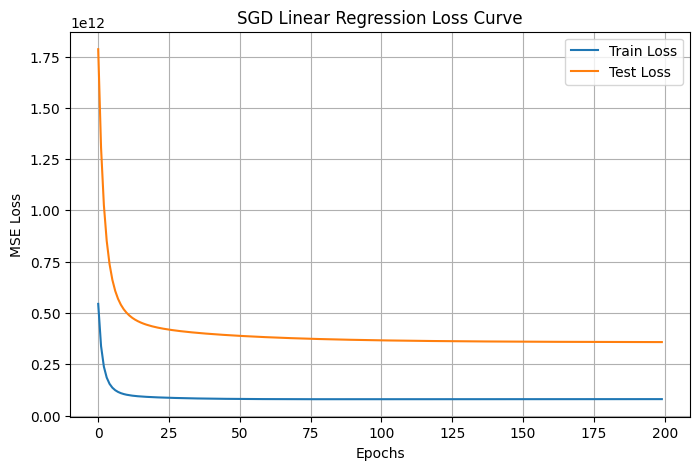

In [ ]:
# Initialize model for gradient descent tracking
sgd_model = SGDRegressor(
    max_iter=1,            # one step at a time
    learning_rate='invscaling',
    eta0=0.01,
    warm_start=True,       # VERY IMPORTANT (keeps learning)
    penalty=None,
    random_state=42
)

train_losses = []
test_losses = []

n_epochs = 200  # keep it smaller for smoother graph

for epoch in range(n_epochs):
    sgd_model.fit(X_train, y_train)  # continues training

    y_train_pred = sgd_model.predict(X_train)
    y_test_pred = sgd_model.predict(X_test)

    train_losses.append(mean_squared_error(y_train, y_train_pred))
    test_losses.append(mean_squared_error(y_test, y_test_pred))

# Plot loss curves
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('SGD Linear Regression Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

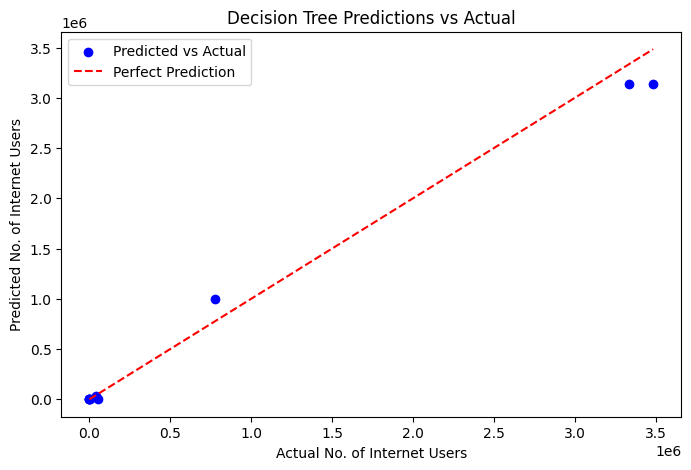

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_test_dt, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual No. of Internet Users')
plt.ylabel('Predicted No. of Internet Users')
plt.title('Decision Tree Predictions vs Actual')
plt.legend()
plt.show()

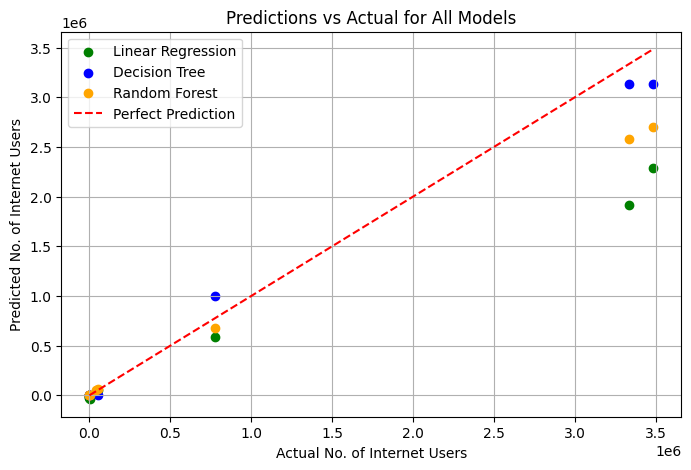

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_test_lr, color='green', label='Linear Regression')
plt.scatter(y_test, y_test_dt, color='blue', label='Decision Tree')
plt.scatter(y_test, y_test_rf, color='orange', label='Random Forest')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual No. of Internet Users')
plt.ylabel('Predicted No. of Internet Users')
plt.title('Predictions vs Actual for All Models')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Save Decision Tree model
joblib.dump(dt_model, 'best_model_rwanda.pkl')

# Save the scaler for new predictions
joblib.dump(scaler, 'scaler_rwanda.pkl')

print("Decision Tree model and scaler saved successfully!")

Decision Tree model and scaler saved successfully!


In [ ]:
# best_model_prediction.py
import joblib
import pandas as pd
import numpy as np

# Load the saved model and scaler
model = joblib.load('best_model_rwanda.pkl')
scaler = joblib.load('scaler_rwanda.pkl')

def predict_internet_users(year, cellular_subscription, broadband_subscription):
    """
    Predict the number of internet users for Rwanda using the best model.

    Parameters:
        year (int): Year
        cellular_subscription (float): Fraction (0.0 - 1.0)
        broadband_subscription (float): Fraction (0.0 - 1.0)

    Returns:
        float: Predicted number of internet users
    """
    # Prepare features as DataFrame
    X_new = pd.DataFrame(
        [[year, cellular_subscription, broadband_subscription]],
        columns=['Year', 'Cellular Subscription', 'Broadband Subscription']
    )

    # Scale features
    X_scaled = scaler.transform(X_new)

    # Predict
    y_pred = model.predict(X_scaled)

    return y_pred[0]

if __name__ == "__main__":
    print("Predict Number of Internet Users in Rwanda")
    print("⚠️ Enter subscription values exactly as in dataset (fractions between 0 and 1)")

    year = float(input("Enter year (e.g., 1998): "))
    cellular_sub = float(input("Enter cellular subscription fraction (e.g., 0.071810): "))
    broadband_sub = float(input("Enter broadband subscription fraction (e.g., 0.0): "))

    predicted_users = predict_internet_users(year, cellular_sub, broadband_sub)
    print(f"\nPredicted number of internet users in {year}: {predicted_users:.0f}")

Predict Number of Internet Users in Rwanda
⚠️ Enter subscription values exactly as in dataset (fractions between 0 and 1)
Enter cellular subscription fraction (e.g., 0.071810): 2026


In [ ]:
from google.colab import drive
drive.mount('/content/drive')